In [8]:
# Define features (X) and target variables (y)
# We will predict both APOAPSIS and PERIAPSIS
X_train = train_df.drop(['APOAPSIS', 'PERIAPSIS', 'NORAD_CAT_ID', 'EPOCH_UNIX'], axis=1)  # Features
y_train = train_df[['APOAPSIS', 'PERIAPSIS']]  # Target variables

X_test = test_df.drop(['APOAPSIS', 'PERIAPSIS', 'NORAD_CAT_ID', 'EPOCH_UNIX'], axis=1) # Features
y_test = test_df[['APOAPSIS', 'PERIAPSIS']]   # Target variables

print("Training set shape (X_train, y_train):", X_train.shape, y_train.shape)
print("Testing set shape (X_test, y_test):", X_test.shape, y_test.shape)

Training set shape (X_train, y_train): (316, 20) (316, 2)
Testing set shape (X_test, y_test): (9353, 20) (9353, 2)


In [7]:
from sklearn.preprocessing import StandardScaler

# Define the features to scale (excluding non-numeric and target columns)
features_to_scale = ['MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'RA_OF_ASC_NODE', 'ARG_OF_PERICENTER',
                     'MEAN_ANOMALY', 'BSTAR', 'ORBITAL_PERIOD', 'SEMI_MAJOR_AXIS', 'ORBITAL_VELOCITY',
                     'PERIGEE_ALTITUDE', 'APOGEE_ALTITUDE', 'ORBIT_SIZE', 'ORBIT_SHAPE',
                     'ORBIT_VELOCITY_SQ', 'INCLINATION_RAD', 'MEAN_MOTION_SQ',
                     'ECCENTRICITY_x_ORBITAL_PERIOD', 'INCLINATION_x_MEAN_MOTION', 'ECCENTRICITY_SQ']

scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and testing data
# Use .copy() to avoid SettingWithCopyWarning
train_df = train_df.copy()
test_df = test_df.copy()

train_df[features_to_scale] = scaler.fit_transform(train_df[features_to_scale])
test_df[features_to_scale] = scaler.transform(test_df[features_to_scale])

display(train_df.head())
display(test_df.head())

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,...,PERIGEE_ALTITUDE,APOGEE_ALTITUDE,ORBIT_SIZE,ORBIT_SHAPE,ORBIT_VELOCITY_SQ,INCLINATION_RAD,MEAN_MOTION_SQ,ECCENTRICITY_x_ORBITAL_PERIOD,INCLINATION_x_MEAN_MOTION,ECCENTRICITY_SQ
5983,38571,1752166943,-1.770237,2.264747,-0.865125,-1.764132,0.595783,1.577505,26638.403,1354.914,...,-0.169137,1.423428,1.060704,1.206108,-1.953625,-0.865125,-1.813429,1.501873,-1.654136,2.230909
8836,56997,1752199706,0.194429,-0.498445,-0.046773,-0.983684,-1.074717,1.671069,1618.828,1497.959,...,-0.143586,-0.455873,-0.404934,-0.342462,0.349964,-0.046773,-0.008099,-0.452556,-0.134805,-0.437389
6908,41519,1752207977,0.893327,-0.520454,0.784015,1.898677,1.050348,-0.917389,410.531,373.520,...,-0.344434,-0.546632,-0.542370,-0.340929,0.817442,0.784015,1.164242,-0.456751,1.124706,-0.437739
7432,43360,1752230035,-0.905162,1.035927,-1.596516,-0.421348,-0.014650,0.059341,9068.056,1094.208,...,-0.215704,0.103662,0.010161,0.258186,-1.325352,-1.596516,-1.289397,0.005234,-1.556671,0.401349
6611,40848,1752252523,-1.997630,2.780746,-1.645081,-0.770236,0.446972,-1.190461,41236.019,897.422,...,-0.250854,2.519902,1.893791,3.397192,-2.074811,-1.645081,-1.880432,3.171417,-1.849409,3.306175


,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,...,PERIGEE_ALTITUDE,APOGEE_ALTITUDE,ORBIT_SIZE,ORBIT_SHAPE,ORBIT_VELOCITY_SQ,INCLINATION_RAD,MEAN_MOTION_SQ,ECCENTRICITY_x_ORBITAL_PERIOD,INCLINATION_x_MEAN_MOTION,ECCENTRICITY_SQ
6199,39608,1754002830,0.637732,-0.526107,0.194026,-0.750177,0.857081,-0.739381,777.066,755.923,...,-0.276129,-0.519101,-0.498245,-0.346856,0.666722,0.194026,0.703237,-0.457434,0.381271,-0.437776
2763,28609,1754004466,0.451472,-0.507693,0.836244,-0.559411,-1.579997,1.625347,1115.654,1032.730,...,-0.226686,-0.493668,-0.461988,-0.342495,0.526335,0.836244,0.390725,-0.454517,0.754299,-0.437577
7657,44697,1754005081,0.576267,-0.524662,0.238223,-0.591231,-1.673714,1.578870,877.519,851.446,...,-0.259067,-0.511555,-0.486699,-0.346635,0.626210,0.238223,0.597925,-0.457200,0.371178,-0.437769
5316,36167,1754005487,0.659478,-0.500989,0.785052,-0.530327,1.052432,-0.923637,782.748,682.480,...,-0.289247,-0.518674,-0.502238,-0.336942,0.648565,0.785052,0.741011,-0.453813,0.907358,-0.437447
5755,37998,1754005795,0.652954,-0.523409,-0.046280,-0.423579,0.539165,-0.448685,757.532,727.939,...,-0.281128,-0.520568,-0.501045,-0.345799,0.672842,-0.046280,0.729651,-0.457049,0.186270,-0.437761


In [5]:
# Split the data into a training and testing set based on the 'EPOCH_UNIX' column.
# This is crucial for a time-series problem to prevent data leakage.
df_sorted = df.sort_values(by='EPOCH_UNIX')

# Define your cutoff point. You may need to adjust this value.
# Find the range using df_sorted['EPOCH_UNIX'].min() and .max()
cutoff_epoch = 1754000000

train_df = df_sorted[df_sorted['EPOCH_UNIX'] < cutoff_epoch]
test_df = df_sorted[df_sorted['EPOCH_UNIX'] >= cutoff_epoch]

print(f"Training set size: {len(train_df)} entries")
print(f"Testing set size: {len(test_df)} entries")

Training set size: 316 entries
Testing set size: 9353 entries


In [4]:
import numpy as np

# Feature Engineering
# Create new features that might be relevant for predicting APOAPSIS and PERIAPSIS
df['ORBIT_SIZE'] = df['SEMI_MAJOR_AXIS'] * 2
df['ORBIT_SHAPE'] = df['APOAPSIS'] / df['PERIAPSIS']
df['ORBIT_VELOCITY_SQ'] = df['ORBITAL_VELOCITY'] ** 2
df['INCLINATION_RAD'] = np.radians(df['INCLINATION'])
df['MEAN_MOTION_SQ'] = df['MEAN_MOTION'] ** 2

# Interaction features (examples)
df['ECCENTRICITY_x_ORBITAL_PERIOD'] = df['ECCENTRICITY'] * df['ORBITAL_PERIOD']
df['INCLINATION_x_MEAN_MOTION'] = df['INCLINATION'] * df['MEAN_MOTION']

# Polynomial features (example)
df['ECCENTRICITY_SQ'] = df['ECCENTRICITY'] ** 2

# Display the first few rows with new features
display(df.head())

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,...,PERIGEE_ALTITUDE,APOGEE_ALTITUDE,ORBIT_SIZE,ORBIT_SHAPE,ORBIT_VELOCITY_SQ,INCLINATION_RAD,MEAN_MOTION_SQ,ECCENTRICITY_x_ORBITAL_PERIOD,INCLINATION_x_MEAN_MOTION,ECCENTRICITY_SQ
0,51,1754742671,12.183623,0.010673,47.2135,293.7644,348.9420,10.9027,1684.833,1514.536,...,-4856.464,-4686.167,15955.639028,1.112442,48.995878,0.824031,148.440669,75.688856,575.231484,0.000114
1,121,1754712212,14.001546,0.009819,66.7470,97.0978,226.1690,133.1247,964.658,821.866,...,-5549.134,-5406.342,14542.793785,1.173741,53.857173,1.164955,196.043286,60.588716,934.561180,0.000096
2,124,1754736595,14.351177,0.007203,66.5460,351.7232,342.1053,17.7511,826.202,723.152,...,-5647.848,-5544.798,14305.624406,1.142501,55.038994,1.161447,205.956288,43.368038,955.013440,0.000052
3,125,1754703788,14.073826,0.007973,66.8774,350.4953,290.9223,68.3344,926.118,810.571,...,-5560.429,-5444.882,14492.958807,1.142550,54.242649,1.167231,198.072570,48.944235,941.220872,0.000064
4,126,1754731663,14.436013,0.005355,66.7075,208.2124,132.9542,227.6073,784.781,708.472,...,-5662.528,-5586.219,14249.523094,1.107709,55.460757,1.164266,208.398468,32.051044,962.990330,0.000029


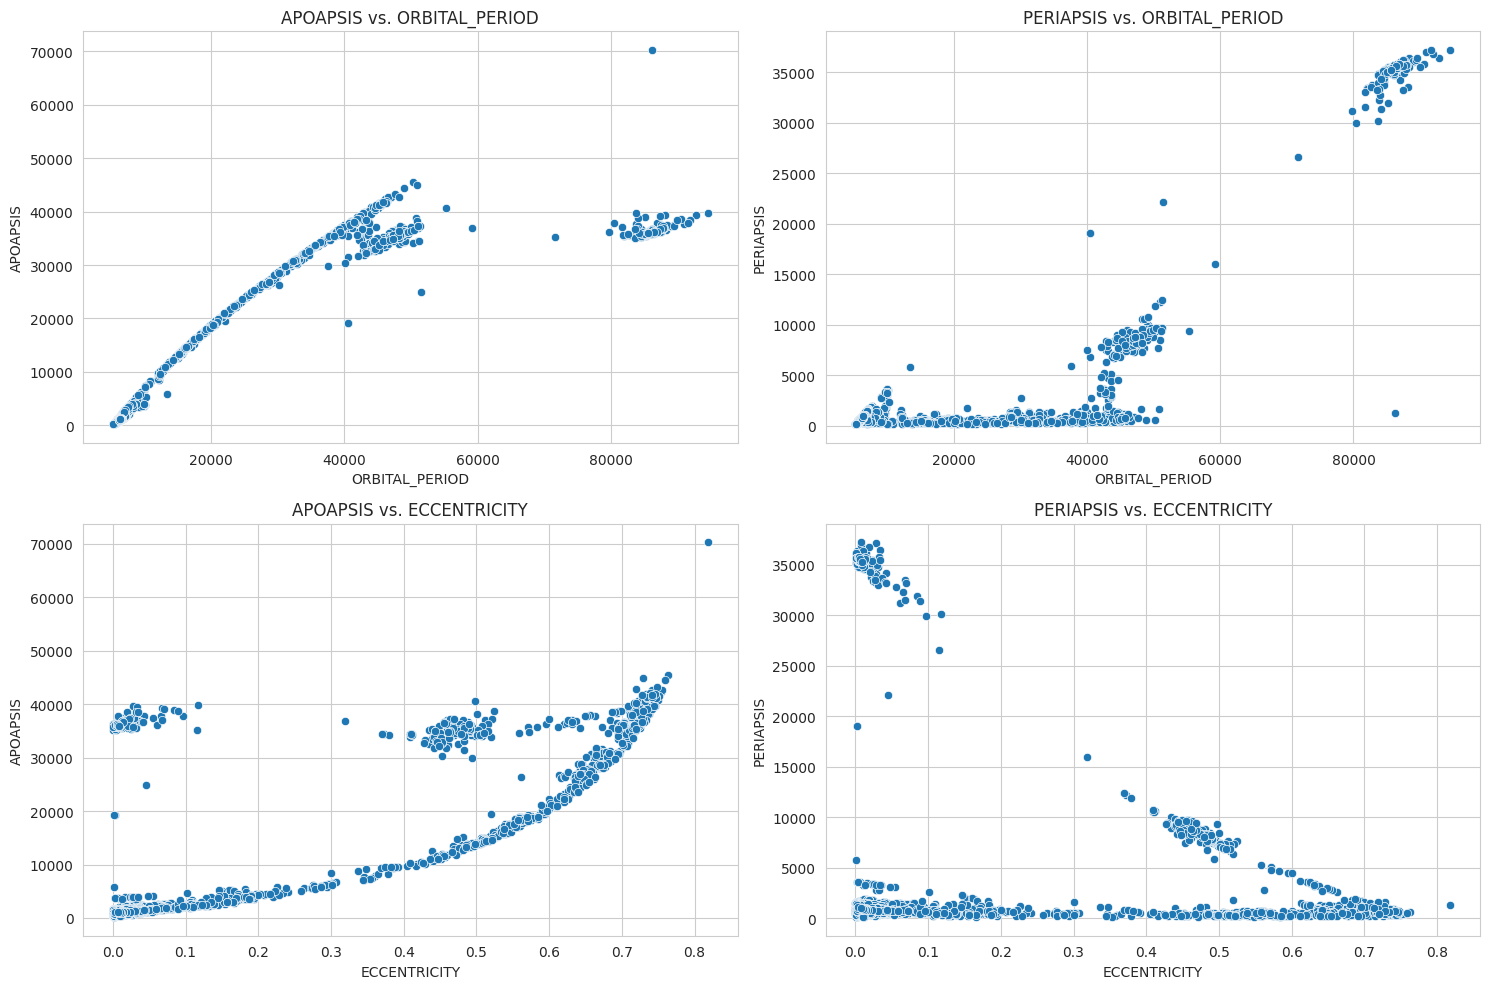

In [3]:
# Explore relationships between orbital parameters and APOAPSIS/PERIAPSIS
plt.figure(figsize=(15, 10))

# Scatter plot of APOAPSIS vs. ORBITAL_PERIOD
plt.subplot(2, 2, 1)
sns.scatterplot(data=df, x='ORBITAL_PERIOD', y='APOAPSIS')
plt.title('APOAPSIS vs. ORBITAL_PERIOD')

# Scatter plot of PERIAPSIS vs. ORBITAL_PERIOD
plt.subplot(2, 2, 2)
sns.scatterplot(data=df, x='ORBITAL_PERIOD', y='PERIAPSIS')
plt.title('PERIAPSIS vs. ORBITAL_PERIOD')

# Scatter plot of APOAPSIS vs. ECCENTRICITY
plt.subplot(2, 2, 3)
sns.scatterplot(data=df, x='ECCENTRICITY', y='APOAPSIS')
plt.title('APOAPSIS vs. ECCENTRICITY')

# Scatter plot of PERIAPSIS vs. ECCENTRICITY
plt.subplot(2, 2, 4)
sns.scatterplot(data=df, x='ECCENTRICITY', y='PERIAPSIS')
plt.title('PERIAPSIS vs. ECCENTRICITY')

plt.tight_layout()
plt.show()

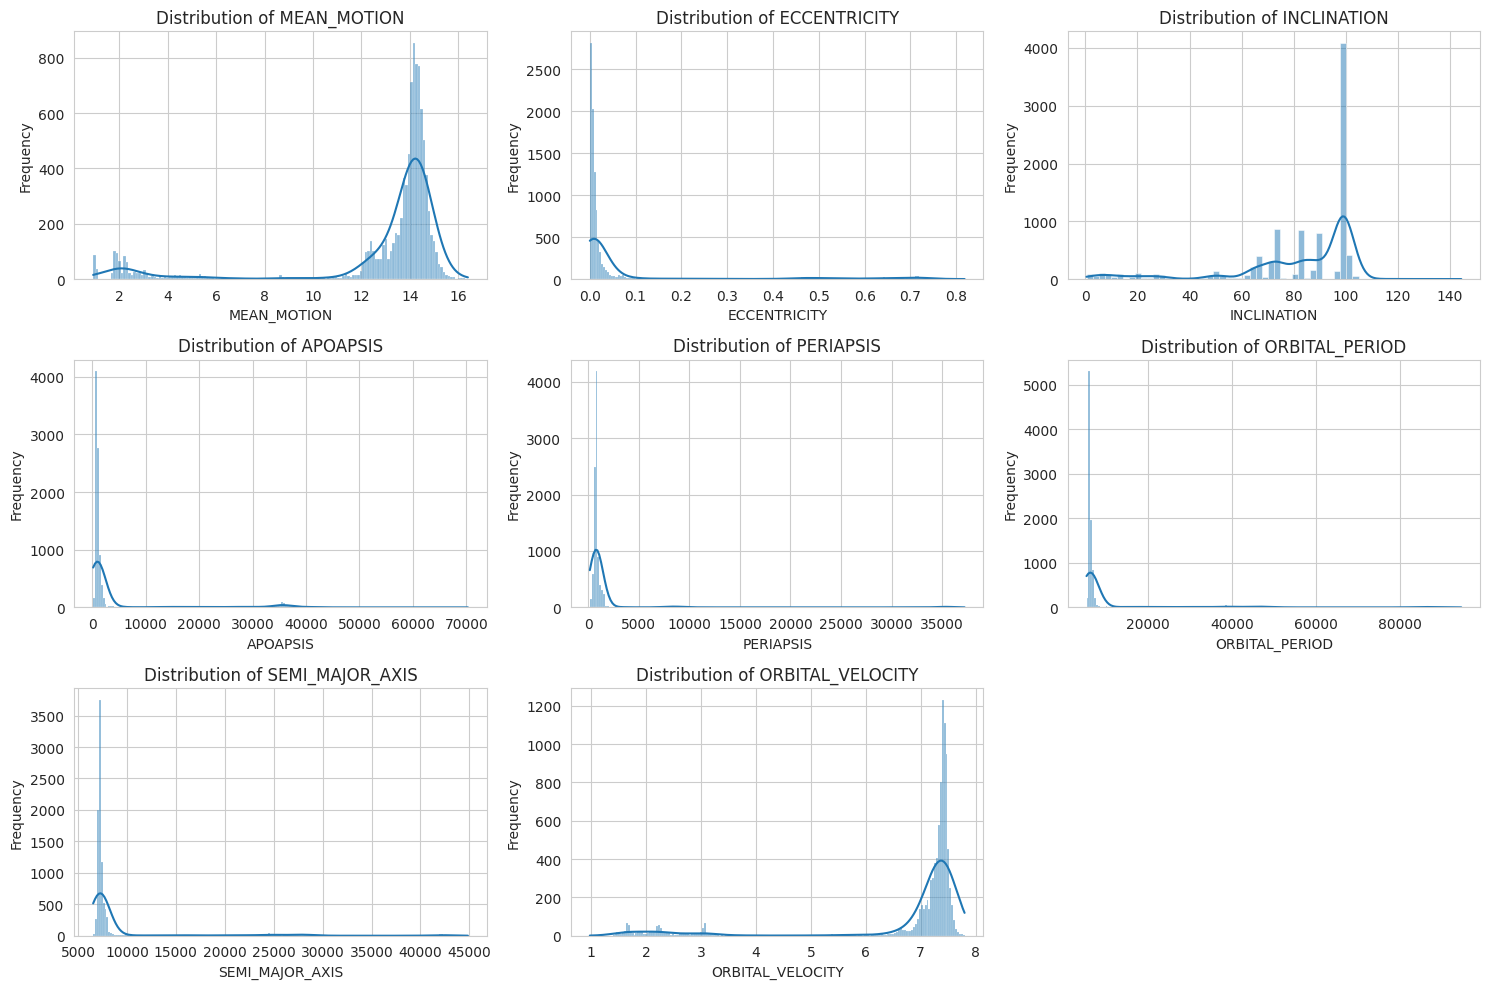

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_style("whitegrid")

# List of orbital parameters to visualize
orbital_parameters = ['MEAN_MOTION', 'ECCENTRICITY', 'INCLINATION', 'APOAPSIS', 'PERIAPSIS', 'ORBITAL_PERIOD', 'SEMI_MAJOR_AXIS', 'ORBITAL_VELOCITY']

# Create histograms for each parameter
plt.figure(figsize=(15, 10))
for i, param in enumerate(orbital_parameters):
    plt.subplot(3, 3, i + 1)
    sns.histplot(df[param], kde=True)
    plt.title(f'Distribution of {param}')
    plt.xlabel(param)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

In [1]:
import pandas as pd

# Load the data
df = pd.read_csv('/content/space_debris_with_engineered_features.csv')

# Display the first few rows and info
display(df.head())
display(df.info())

,NORAD_CAT_ID,EPOCH_UNIX,MEAN_MOTION,ECCENTRICITY,INCLINATION,RA_OF_ASC_NODE,ARG_OF_PERICENTER,MEAN_ANOMALY,APOAPSIS,PERIAPSIS,BSTAR,ORBITAL_PERIOD,SEMI_MAJOR_AXIS,ORBITAL_VELOCITY,PERIGEE_ALTITUDE,APOGEE_ALTITUDE
0,51,1754742671,12.183623,0.010673,47.2135,293.7644,348.9420,10.9027,1684.833,1514.536,0.000467,7091.486668,7977.819514,6.999706,-4856.464,-4686.167
1,121,1754712212,14.001546,0.009819,66.7470,97.0978,226.1690,133.1247,964.658,821.866,0.000061,6170.747215,7271.396893,7.338745,-5549.134,-5406.342
2,124,1754736595,14.351177,0.007203,66.5460,351.7232,342.1053,17.7511,826.202,723.152,0.000159,6020.412027,7152.812203,7.418827,-5647.848,-5544.798
3,125,1754703788,14.073826,0.007973,66.8774,350.4953,290.9223,68.3344,926.118,810.571,0.000066,6139.055699,7246.479404,7.364961,-5560.429,-5444.882
4,126,1754731663,14.436013,0.005355,66.7075,208.2124,132.9542,227.6073,784.781,708.472,0.000427,5985.032062,7124.761547,7.447198,-5662.528,-5586.219


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9669 entries, 0 to 9668
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   NORAD_CAT_ID       9669 non-null   int64  
 1   EPOCH_UNIX         9669 non-null   int64  
 2   MEAN_MOTION        9669 non-null   float64
 3   ECCENTRICITY       9669 non-null   float64
 4   INCLINATION        9669 non-null   float64
 5   RA_OF_ASC_NODE     9669 non-null   float64
 6   ARG_OF_PERICENTER  9669 non-null   float64
 7   MEAN_ANOMALY       9669 non-null   float64
 8   APOAPSIS           9669 non-null   float64
 9   PERIAPSIS          9669 non-null   float64
 10  BSTAR              9669 non-null   float64
 11  ORBITAL_PERIOD     9669 non-null   float64
 12  SEMI_MAJOR_AXIS    9669 non-null   float64
 13  ORBITAL_VELOCITY   9669 non-null   float64
 14  PERIGEE_ALTITUDE   9669 non-null   float64
 15  APOGEE_ALTITUDE    9669 non-null   float64
dtypes: float64(14), int64(2)

None

In [1]:
!pip install pandas numpy scikit-learn tensorflow matplotlib plotly skyfield --upgrade

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 89.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 108.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 83.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.8/9.8 MB 96.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.0/367.0 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 16.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 89.2 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing ins